# Exploratory Quantification of OCT Barcoding Artifacts

## Objective

The purpose of this notebook is to perform an initial exploratory analysis of the OCT "barcoding" phenomenon observed in patients with advanced dry AMD.

The barcoding pattern appears as a series of vertically oriented transmission artifacts extending into the choroid beneath regions of RPE degeneration. Although the pattern is visually apparent to expert readers, there is currently no standardized quantitative measure of its severity.

Our long-term goal is to develop an objective biomarker that can:

1. Quantify the severity of barcoding from a single OCT scan.
2. Assess reproducibility across scans and patients.
3. Evaluate whether barcoding provides prognostic information regarding future AMD progression.

## Objectives of This Notebook

This notebook focuses on the first stage of the project:

> Can the barcoding phenomenon be measured quantitatively from OCT images?

To begin addressing this question, we:

- Load representative OCT scans exhibiting prominent barcoding.
- Identify image regions containing the transmission artifact.
- Convert visual observations into quantitative image-derived signals.
- Explore simple intensity-based measures of barcoding severity.
- Assess whether one-dimensional transmission profiles capture the visual pattern observed by clinicians.

## Expected Outcome

By the end of this notebook we aim to determine whether simple transmission-profile based measurements provide a reasonable quantitative representation of the barcoding artifact, or whether more advanced texture-analysis methods will be required.

In [1]:
from pathlib import Path

DATA_DIR = Path("../data/amd_best")

image_paths = sorted(DATA_DIR.glob("*.tif"))

print(image_paths)

[PosixPath('../data/amd_best/amd_sample1.tif'), PosixPath('../data/amd_best/amd_sample2.tif'), PosixPath('../data/amd_best/amd_sample3.tif')]


In [2]:
from skimage import io

img = io.imread(image_paths[0])

print("Shape:", img.shape)
print("Dtype:", img.dtype)
print("Min:", img.min())
print("Max:", img.max())

Shape: (496, 768, 3)
Dtype: uint8
Min: 0
Max: 255


Shape: (496, 768)
Min: 0.0
Max: 1.0


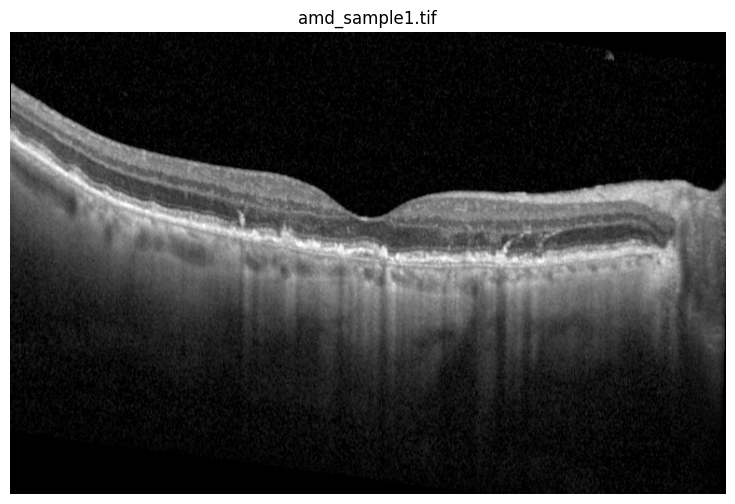

In [3]:
# Convert images to grayscale
from skimage import color, exposure
import matplotlib.pyplot as plt

img_gray = color.rgb2gray(img)

img_norm = exposure.rescale_intensity(
    img_gray,
    in_range="image",
    out_range=(0, 1)
)

print("Shape:", img_norm.shape)
print("Min:", img_norm.min())
print("Max:", img_norm.max())

plt.figure(figsize=(12, 6))
plt.imshow(img_norm, cmap="gray")
plt.title(image_paths[0].name)
plt.axis("off")
plt.show()

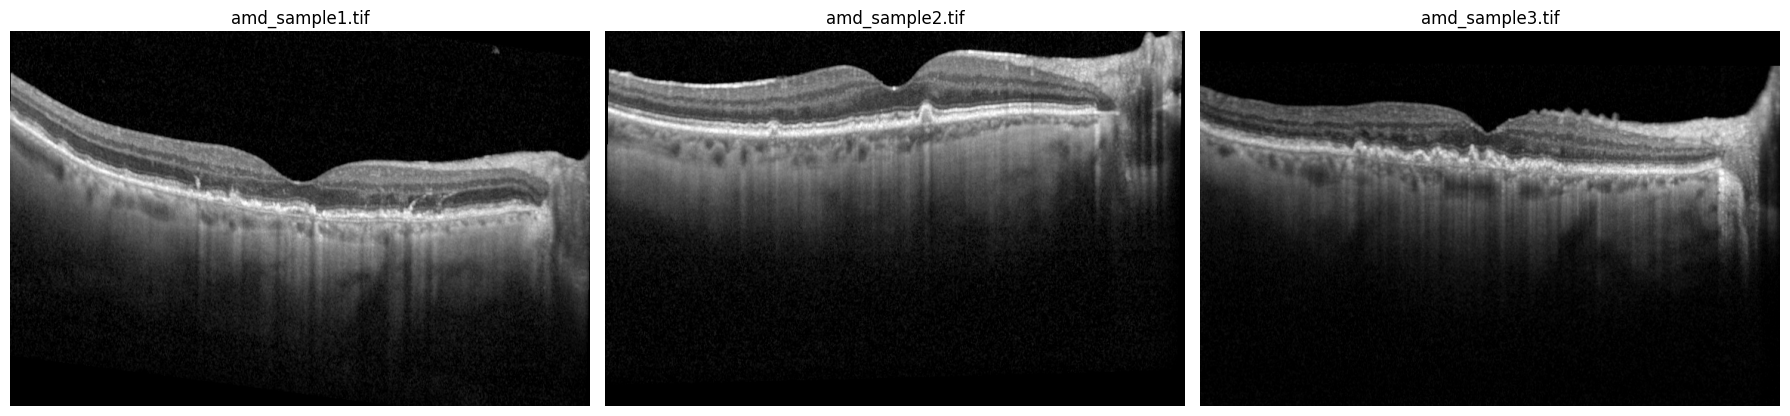

In [4]:
fig, axes = plt.subplots(1, len(image_paths), figsize=(18, 6))

for ax, path in zip(axes, image_paths):
    img = io.imread(path)
    img_gray = color.rgb2gray(img)
    img_norm = exposure.rescale_intensity(img_gray, in_range="image", out_range=(0, 1))

    ax.imshow(img_norm, cmap="gray")
    ax.set_title(path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Region of Interest Selection

The barcoding phenomenon is visually observed as vertically oriented transmission artifacts extending into the choroid beneath regions of RPE degeneration. Because our objective is to quantify these artifacts, analysis should be restricted to the anatomical region where the phenomenon occurs.

Including unrelated structures such as the vitreous, retinal layers, or large regions of background darkness may introduce variability unrelated to the barcoding pattern and dilute quantitative measurements.

### Initial ROI Strategy

For this exploratory analysis, a simple rectangular crop was used rather than automated retinal layer segmentation. The goal is to rapidly evaluate whether the artifact is measurable before developing more sophisticated image-processing pipelines.

Several candidate crops were visually inspected:

| Crop Range | Notes |
|------------|-------|
| `180:420` | Captured the barcoding region but included substantial low-information background signal in the lower portion of the image. |
| `180:350` | Retained the RPE/choroidal interface and most visible transmission columns while removing much of the background darkness. |
| `180:330` | Considered as a more aggressive crop but risked excluding portions of deeper transmission artifacts. |

Based on visual inspection, the crop `180:350` was selected for the initial analysis.

### Anatomical Structures Included

The selected ROI contains:

- The RPE/Bruch's membrane complex near the upper boundary.
- Regions of increased transmission associated with RPE disruption.
- The upper and mid-choroid where the vertical stripe pattern is most apparent.

The selected ROI largely excludes:

- Vitreous.
- Most neurosensory retina.
- Large regions of low-information background.

### Rationale

The purpose of ROI selection is not to isolate a specific pathology but rather to focus quantitative analysis on the region where clinicians visually identify the barcoding pattern.

At this stage, the ROI is intended as a proof-of-concept region for feature extraction. Future work may replace manual cropping with automated retinal layer segmentation or choroidal boundary detection to improve reproducibility and scalability.

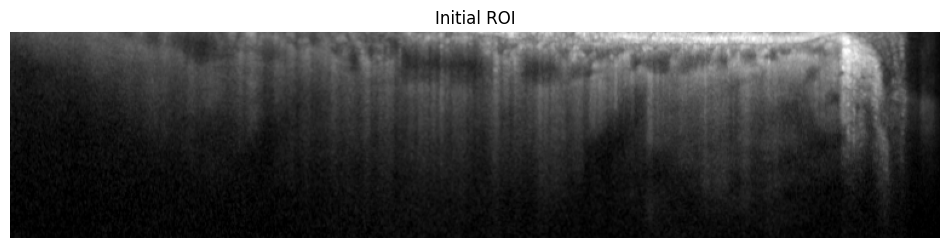

In [6]:
# Define region of interest
roi = img_norm[
    180:350,
    :
]

plt.figure(figsize=(12,5))

plt.imshow(
    roi,
    cmap="gray"
)

plt.axis("off")
plt.title("Initial ROI")

plt.show()

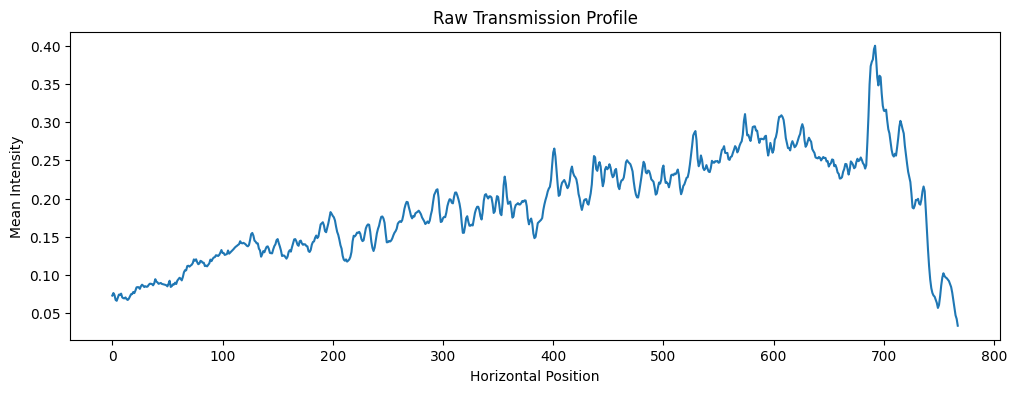

In [7]:
T = roi.mean(axis=0)

plt.figure(figsize=(12,4))

plt.plot(T)

plt.title("Raw Transmission Profile")
plt.xlabel("Horizontal Position")
plt.ylabel("Mean Intensity")

plt.show()

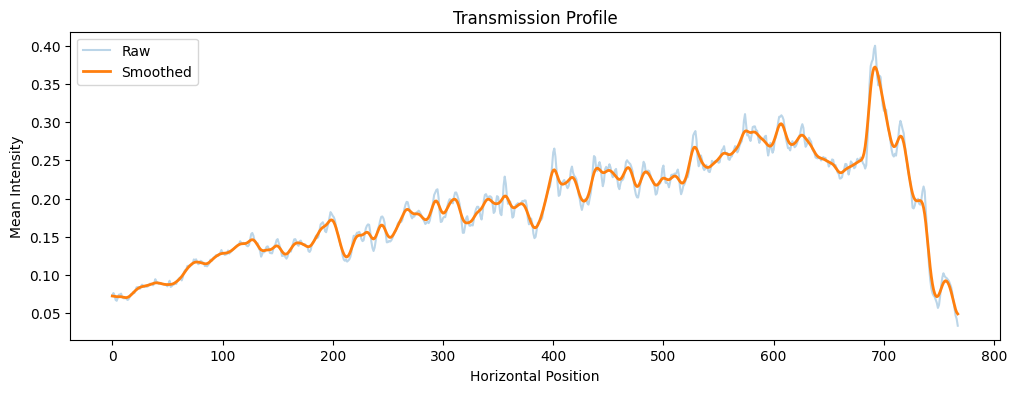

In [8]:
from scipy.ndimage import gaussian_filter1d

T_smooth = gaussian_filter1d(
    T,
    sigma=3
)

plt.figure(figsize=(12,4))

plt.plot(T, alpha=0.3, label="Raw")
plt.plot(T_smooth, linewidth=2, label="Smoothed")

plt.legend()

plt.title("Transmission Profile")
plt.xlabel("Horizontal Position")
plt.ylabel("Mean Intensity")

plt.show()

## Transmission Profile Analysis

To obtain a simple quantitative representation of the barcoding pattern, the 2D ROI was reduced to a 1D transmission profile.

For each horizontal position $x$, the average pixel intensity within the ROI was computed:

$$
T(x)
=
\frac{1}{H}
\sum_{z=1}^{H}
I(x,z),
$$

where:

- $I(x,z)$ denotes image intensity,
- $H$ is the height of the ROI,
- $T(x)$ represents the average transmission signal at horizontal position $x$.

Conceptually, this profile measures how much light is transmitted through the retina and into the choroid across the scan.

The blue curve represents the raw transmission profile, while the orange curve represents a Gaussian-smoothed version intended to highlight broader trends and reduce local noise.

### Initial Observations

Several features are immediately apparent:

- The transmission profile exhibits a strong large-scale intensity gradient from left to right.
- Local fluctuations are present throughout the scan.
- Regions of increased transmission correspond to areas where the vertical barcoding pattern appears visually prominent.
- A particularly strong increase in transmission is observed near the far right side of the image.

### Interpretation

The overall trend appears to be driven primarily by large-scale brightness variations within the scan rather than by the barcoding artifact itself.

This suggests that the raw transmission profile captures a combination of:

- Global illumination effects,
- Anatomical variation,
- Choroidal brightness differences,
- Localized transmission artifacts.

Consequently, the barcode-related signal is likely embedded within smaller fluctuations superimposed on the broader intensity trend.

### Next Step

To better isolate potential barcode-related information, the large-scale trend will be removed from the transmission profile. The resulting residual signal will allow us to investigate whether the vertical transmission columns produce measurable oscillatory patterns that are not explained by overall image brightness.

This detrended profile serves as the first attempt to separate the barcoding signal from broader anatomical and imaging effects.

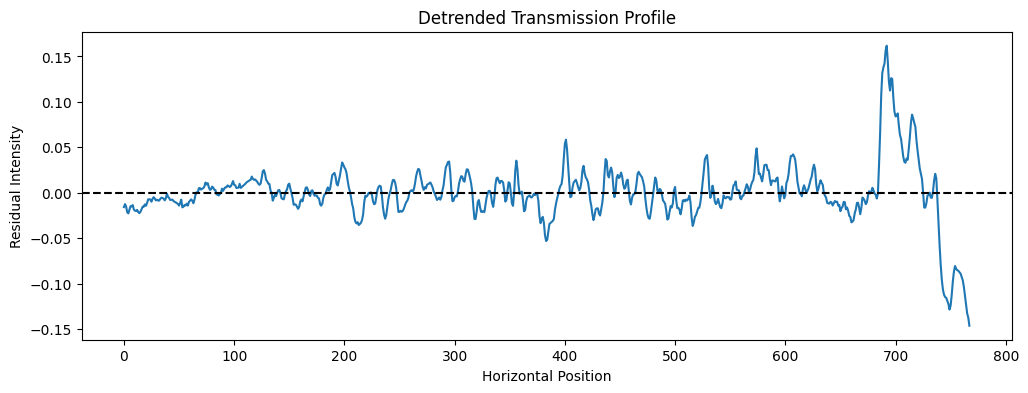

In [9]:
from scipy.ndimage import gaussian_filter1d

trend = gaussian_filter1d(
    T,
    sigma=50
)

T_detrended = T - trend

plt.figure(figsize=(12,4))

plt.plot(T_detrended)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Detrended Transmission Profile")
plt.xlabel("Horizontal Position")
plt.ylabel("Residual Intensity")

plt.show()

## Detrended Transmission Profile

The transmission profile shown previously contained a strong large-scale intensity gradient across the image. While this trend reflects overall variations in image brightness and transmission, it may obscure smaller fluctuations associated with the barcoding pattern.

To isolate local structure, a heavily smoothed trend was estimated and subtracted from the original transmission profile:

$$
T_{\text{detrended}}(x)
=
T(x)
-
\hat{T}(x),
$$

where:

- $T(x)$ is the original transmission profile,
- $\hat{T}(x)$ is a smoothed estimate of the large-scale intensity trend,
- $T_{\text{detrended}}(x)$ represents local deviations from that trend.

The resulting signal is centered approximately around zero and highlights short-scale fluctuations that are not explained by overall image brightness.

### Initial Observations

Several observations emerge from the detrended profile:

- The large left-to-right intensity gradient has been largely removed.
- Local oscillations are now more visible throughout the scan.
- The signal exhibits numerous small peaks and valleys rather than a smooth periodic pattern.
- Several larger excursions are present, particularly near the right side of the image.
- No obvious single dominant wavelength is apparent.

### Interpretation

If the barcoding phenomenon behaved like a highly regular repeating pattern, one might expect a relatively consistent oscillatory signal after detrending.

Instead, the residual profile appears irregular, suggesting that the artifact may not be well-described as a simple periodic process.

This observation is consistent with visual inspection of the OCT images, where the transmission columns appear:

- Localized,
- Variable in width,
- Variable in spacing,
- Non-uniform across the scan.

Consequently, the barcoding phenomenon may be better characterized as a directional texture pattern rather than a strictly periodic signal.

### Implications for Feature Development

This preliminary result suggests that simple transmission-profile statistics may not fully capture the visual characteristics of barcoding.

While measures such as:

- Residual variance,
- Residual standard deviation,
- Peak count,

provide useful quantitative summaries, they do not explicitly encode the strong vertical orientation of the observed artifact.

Future analyses will therefore investigate image-analysis methods that preserve two-dimensional spatial structure, including:

- Gabor filters,
- Structure tensor analysis,
- Local anisotropy measures,

which are specifically designed to quantify oriented texture patterns.

In [10]:
import numpy as np

barcode_std = np.std(T_detrended)
barcode_var = np.var(T_detrended)

print(f"STD: {barcode_std:.4f}")
print(f"VAR: {barcode_var:.6f}")

from scipy.signal import find_peaks

peaks, _ = find_peaks(
    T_detrended,
    prominence=0.02
)

print("Number of peaks:", len(peaks))

STD: 0.0325
VAR: 0.001057
Number of peaks: 27


## Preliminary Summary Statistics

To provide a simple quantitative description of the detrended transmission profile, several summary statistics were computed:

- **Standard Deviation (STD):** 0.0325
- **Variance (VAR):** 0.001057
- **Number of Peaks:** 27

The standard deviation and variance measure the overall magnitude of fluctuations in the detrended signal. Larger values indicate greater local variability in transmission intensity.

The peak count measures the number of prominent local maxima identified in the detrended profile. This provides a rough estimate of the complexity of the signal and the frequency of localized transmission features across the scan.

These statistics represent an initial attempt to summarize the barcoding pattern numerically. However, because they are derived from a one-dimensional transmission profile, they do not explicitly capture the vertical orientation of the artifact and should be viewed as exploratory features rather than definitive measures of barcoding severity.

# Apply to all three images

In [11]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
import numpy as np

def transmission_features(roi, trend_sigma=50, peak_prominence=0.02):
    T = roi.mean(axis=0)
    trend = gaussian_filter1d(T, sigma=trend_sigma)
    T_detrended = T - trend

    peaks, _ = find_peaks(T_detrended, prominence=peak_prominence)

    return {
        "std": np.std(T_detrended),
        "var": np.var(T_detrended),
        "peak_count": len(peaks),
        "profile": T,
        "detrended_profile": T_detrended,
        "peaks": peaks,
    }

In [12]:
import pandas as pd
results = []

for path in image_paths:
    img = io.imread(path)
    img_gray = color.rgb2gray(img)
    img_norm = exposure.rescale_intensity(img_gray, in_range="image", out_range=(0, 1))

    roi = img_norm[180:350, :]

    feats = transmission_features(roi)

    results.append({
        "image": path.name,
        "std": feats["std"],
        "var": feats["var"],
        "peak_count": feats["peak_count"],
    })

pd.DataFrame(results)

,image,std,var,peak_count
0,amd_sample1.tif,0.025412,0.000646,27
1,amd_sample2.tif,0.019957,0.000398,24
2,amd_sample3.tif,0.032513,0.001057,27


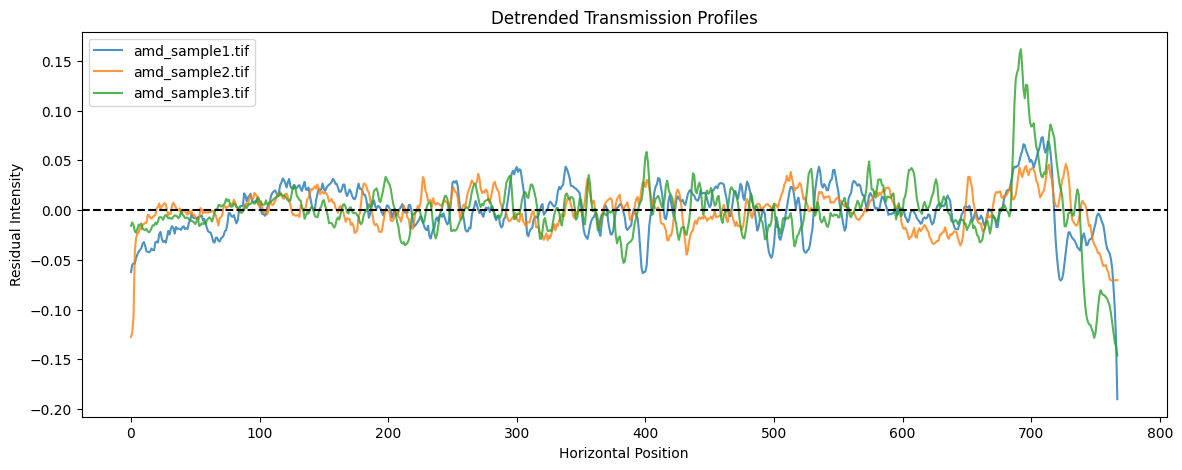

In [13]:
plt.figure(figsize=(14, 5))

for path in image_paths:
    img = io.imread(path)
    img_gray = color.rgb2gray(img)
    img_norm = exposure.rescale_intensity(img_gray, in_range="image", out_range=(0, 1))
    roi = img_norm[180:350, :]

    feats = transmission_features(roi)

    plt.plot(
        feats["detrended_profile"],
        label=path.name,
        alpha=0.8
    )

plt.axhline(0, color="black", linestyle="--")
plt.title("Detrended Transmission Profiles")
plt.xlabel("Horizontal Position")
plt.ylabel("Residual Intensity")
plt.legend()
plt.show()

## Comparison Across Representative Barcoding Examples

To assess whether the transmission-profile approach captures differences between scans, the detrended transmission profiles and associated summary statistics were compared across all three representative examples.

### Summary Statistics

| Image | Standard Deviation | Variance | Peak Count |
|---------|---------:|---------:|---------:|
| amd\_sample1.tif | 0.0254 | 0.000646 | 27 |
| amd\_sample2.tif | 0.0200 | 0.000398 | 24 |
| amd\_sample3.tif | 0.0325 | 0.001057 | 27 |

### Observations

Several observations emerge from this comparison:

- All three scans exhibit broadly similar detrended transmission patterns.
- The residual signals oscillate around zero after removal of the large-scale intensity trend.
- The estimated peak counts are relatively similar across scans.
- Sample 3 exhibits the largest residual variability, as reflected by both the standard deviation and variance.
- Sample 2 exhibits the smallest residual variability despite appearing visually prominent during qualitative inspection.

### Interpretation

A notable finding is that the quantitative rankings do not perfectly align with visual impressions of barcoding severity.

If the transmission profile fully captured the barcoding phenomenon, one might expect scans that appear more strongly affected to consistently exhibit larger variability measures or higher peak counts. Instead, the numerical differences between scans are relatively modest and do not clearly separate the examples.

This suggests that the one-dimensional transmission profile may be losing important information contained in the original OCT image.

### Preliminary Conclusion

The transmission-profile approach successfully converts OCT images into measurable signals and provides several simple quantitative features. However, the results suggest that these features alone may not adequately characterize the visually apparent barcoding pattern.

Because the artifact is inherently:

- Two-dimensional,
- Directional,
- Localized,
- Irregularly spaced,

future analyses should focus on methods that explicitly preserve spatial and directional information. Candidate approaches include Gabor filters, structure tensor analysis, and anisotropy-based texture measures.

The transmission-profile analysis therefore serves as a useful baseline and proof of concept, while also motivating the need for more sophisticated image-analysis techniques.

# Gabor Filter Exploration

## Motivation

The previous analysis reduced the OCT image to a one-dimensional transmission profile. While this provided a simple quantitative representation of the image, the resulting features did not clearly distinguish between visually different examples of barcoding.

One possible explanation is that the transmission profile discards information about the spatial organization of the artifact.

Clinically, the barcoding phenomenon is characterized not only by variations in intensity, but also by the presence of vertically oriented transmission columns extending into the choroid.

Consequently, the artifact may be better viewed as a directional texture pattern rather than a one-dimensional signal.

## Why Gabor Filters?

Gabor filters are commonly used in image analysis to detect structures with specific:

- Orientations,
- Spatial frequencies,
- Local texture patterns.

Unlike the transmission profile, Gabor filters preserve the two-dimensional structure of the image.

Because the observed barcoding pattern consists of vertically oriented transmission columns, a vertically oriented Gabor filter provides a natural first test of whether the artifact can be characterized as an oriented texture.

## Objective

The goal of this exploratory analysis is not yet to construct a final biomarker.

Instead, we seek to answer a simpler question:

> Do vertical texture detectors respond strongly to the visually apparent barcoding pattern?

If so, Gabor-based features may provide a more informative representation of barcoding severity than transmission-profile statistics alone.

The initial frequency of 0.08 was selected as a reasonable exploratory value based on visual inspection of stripe spacing. In future analyses, a range of frequencies will be evaluated to determine which spatial scales best characterize the barcoding pattern.

In [14]:
from skimage.filters import gabor

frequency = 0.08

real, imag = gabor(
    roi,
    frequency=frequency
)

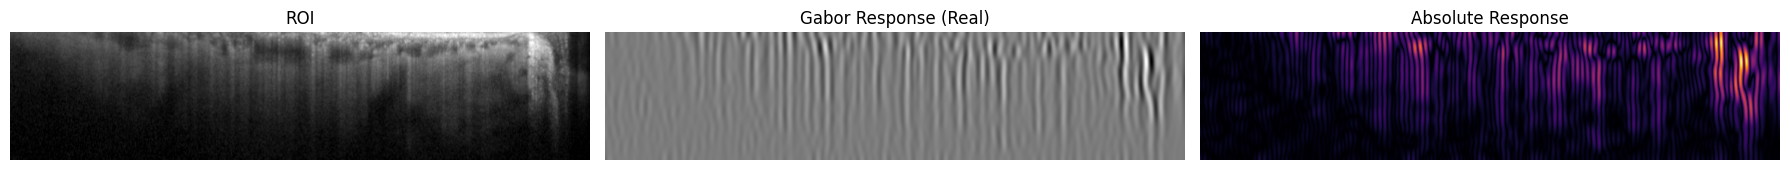

In [15]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

ax[0].imshow(
    roi,
    cmap="gray"
)
ax[0].set_title("ROI")
ax[0].axis("off")

ax[1].imshow(
    real,
    cmap="gray"
)
ax[1].set_title("Gabor Response (Real)")
ax[1].axis("off")

ax[2].imshow(
    np.abs(real),
    cmap="inferno"
)
ax[2].set_title("Absolute Response")
ax[2].axis("off")

plt.tight_layout()
plt.show()

## Preliminary Gabor Filter Results

The Gabor response maps provide the first image-based representation that explicitly incorporates directional information.

Unlike the transmission-profile analysis, which reduced the OCT image to a one-dimensional signal, the Gabor filter operates directly on the two-dimensional image and responds preferentially to structures with a specified orientation and spatial frequency.

### Observations

Several observations are apparent from the response maps:

- Strong responses occur in regions containing visible transmission columns.
- The response preserves the spatial location of the artifact.
- Regions lacking obvious vertical structure exhibit substantially weaker responses.
- The filter highlights directional texture patterns that are not easily captured by column-averaged intensity measurements.

### Interpretation

These results suggest that the barcoding phenomenon may be better characterized as an oriented texture pattern rather than a simple oscillatory signal.

The response maps appear to correspond more closely to visual assessments of barcoding severity than the transmission-profile statistics developed earlier in this notebook.

Consequently, methods that preserve spatial and directional information may provide a more suitable framework for quantifying barcoding than one-dimensional intensity summaries alone.

### Preliminary Conclusion

The Gabor filter successfully detects the vertical transmission structures that define the visual appearance of barcoding.

This finding motivates further investigation of texture-based image-analysis methods, including:

- Multi-scale Gabor features,
- Structure tensor analysis,
- Local anisotropy measures,
- Composite texture-based barcoding indices.

These approaches will be explored in subsequent notebooks.

In [16]:
gabor_score = np.mean(np.abs(real))

print(gabor_score)

0.00337070443944242


In [17]:
results_gabor = []

for path in image_paths:

    img = io.imread(path)
    img_gray = color.rgb2gray(img)
    img_norm = exposure.rescale_intensity(
        img_gray,
        in_range="image",
        out_range=(0,1)
    )

    roi = img_norm[180:350, :]

    real, imag = gabor(
        roi,
        frequency=0.08
    )

    results_gabor.append({
        "image": path.name,
        "gabor_score": np.mean(np.abs(real))
    })

pd.DataFrame(results_gabor)

,image,gabor_score
0,amd_sample1.tif,0.004433
1,amd_sample2.tif,0.002558
2,amd_sample3.tif,0.003371


## Summary of Preliminary Gabor Results

To obtain an initial quantitative measure of texture strength, a simple Gabor score was computed for each image using the mean absolute filter response:

$$
B_G
=
\frac{1}{N}
\sum_{x,y}
|R(x,y)|,
$$

where:

- $R(x,y)$ denotes the Gabor filter response,
- $N$ is the number of pixels in the ROI,
- $B_G$ represents the average magnitude of the detected texture pattern.

### Results

| Image | Gabor Score |
|---------|---------:|
| amd\_sample1.tif | 0.004433 |
| amd\_sample2.tif | 0.002558 |
| amd\_sample3.tif | 0.003371 |

### Interpretation

The Gabor scores demonstrate that the filter is successfully detecting structured texture within each ROI and provides a simple quantitative summary of the response strength.

However, similar to the transmission-profile analysis, the resulting ranking does not perfectly align with visual assessments of barcoding severity. For example, the visually prominent artifact observed in Sample 2 does not produce the largest score.

This outcome is not unexpected. The current analysis uses:

- A single ROI definition,
- A single Gabor frequency,
- A single filter orientation,
- A simple mean-response summary statistic.

As a result, the present scores should be viewed as proof-of-concept measurements rather than optimized biomarkers.

### Conclusions from Notebook 01

Several important findings emerged from this exploratory analysis:

1. The barcoding artifact is visually prominent and appears measurable.
2. Simple transmission-profile statistics do not fully capture the visual appearance of barcoding.
3. Gabor filters respond strongly to the vertical transmission structures present in the OCT images.
4. Preserving two-dimensional spatial information appears important for quantifying the artifact.
5. Additional work is needed to determine which texture features best correspond to clinical assessments of barcoding severity.

The results of this notebook support continued investigation of texture-based image-analysis methods. In particular, the next stage of the project will focus on systematic development of Gabor-based features, including exploration of multiple frequencies, orientations, and summary statistics to better characterize the barcoding phenomenon.